# Analysis and creating figures
This notebook contains the code for visualising findings.


In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import calendar
import plotly.express as px
import numpy as np
from math import ceil
import numpy as np
from scipy.stats import chi2_contingency


## Data Loading

Load the full dataset to be able to do comparisons with the labelled and mapped dataset. The full dataset contains all the subtitles, while the labelled and mapped dataset contains only the ones that were labelled and mapped to topics.

In [15]:
full_dataset = pd.read_csv('../data/subtitles_classified.csv', index_col=0)
full_dataset.head()

,Unnamed: 0,filename,program,year,text_clean,ai_related,matched_keywords_title,matched_keywords_body,matched_keywords_all,n_hits_title_total,n_hits_body_total,company_hits
0,0,"2017-11-27-19,01-1",DE WERELD DRAAIT DOOR,2017,Goedenavond dit is De Wereld Draait Door van m...,no,[],[],[],0,0,[]
1,1,GOEDEMORGEN_N-WON02205666,Goedemorgen Nederland,2021,888\nWelkom terug bij Goedemorgen Nederland.\n...,no,[],[],[],0,0,[]
2,2,GOEDEMORGEN_N-WON02094879,Goedemorgen Nederland,2020,"888\nGoedemorgen Nederland, het is vandaag maa...",no,[],[],[],0,0,['twitter']
3,3,"2017-03-17-08,11-1",GOEDEMORGEN NEDERLAND,2017,Het grote schuiven is begonnen:\nWelke politie...,no,[],[],[],0,0,"['facebook', 'twitter']"
4,4,GOEDEMORGEN_N-WON02199391,Goedemorgen Nederland,2021,888\nWelkom terug bij Goedemorgen Nederland.\n...,no,[],[],[],0,0,[]


In [7]:
df = pd.read_csv('../data/subs_labelled_mapped.csv', index_col=0)
df.head()

,program,year,text_clean,ai_related,matched_keywords_all,relevant_section,processed,nouns,adjectives,verbs,topic,probability,topic_norm,topic_label,topic_meta
0,de wereld draait door,2016,"Eelco Bosch van Rosenthal, Dirk Jan Roeleven, ...",yes,"['facebook', 'google', 'twitter', 'algoritme']",...uit Amerika.\nVanochtend geland.\nHet Ameri...,documentaire voetspor undateables seizoen rufu...,documentaire voetspor undateables seizoen rufu...,mooi lang nieuw nepnieuws ander voorafgaand Am...,landen zien maken hebben zeggen willen tegenga...,6,0.102652,6,journalism and media,"MEDIA, ARTS, CULTURE & SPORTS"
1,jinek,2016,Uitzending bijwonen? Dat kan. Ga naar jinek.kr...,yes,['drones'],...over.\nEn onze tennisdames verrasten de wer...,tennisdame wereld baan klap sensatie nieuws po...,tennisdame wereld baan klap sensatie nieuws po...,regelrecht ander vorig Nederlands internationa...,verrasten meppen beslissen winnen bekennen opl...,0,0.136302,0,war and politics,AI WARFARE & MILIRTARY CONFLICTS
2,goedemorgen nederland,2023,en Joodse scholen die hun deuren vandaag dicht...,yes,"['ai', 'kunstmatige intelligentie']",...en de neus van de politie.\nWeet u hoe een ...,neus politie drugslab mens aanraking drug init...,neus politie drugslab mens aanraking drug init...,goed bewuster kunstmatig welmoed hoog laag dir...,weten werken weten denken komen vinden maken z...,19,1.000000,19,health and science,SCIENCE & HEALTH
3,goedemorgen nederland,2022,888\nWelkom terug bij Goedemorgen Nederland.\n...,yes,"['twitter', 'kunstmatige intelligentie']",...zegt de Britse minister van buitenlandse za...,minister zaak aanval aanval gemeenschap aanval...,minister zaak aanval aanval gemeenschap aanval...,Brits buitenlands roekeloos serieus internatio...,zeggen zeggen nemen doen nemen doen veroordele...,1,0.099202,1,public discourse and societal trends,SOCIETY
4,goedemorgen nederland,2020,888\nWelkom terug bij Goedemorgen Nederland.\n...,yes,['drone'],...er aardig uit.\nIs het een quarantainecoup?...,quarantainecoup filmp laag respect kappersvak ...,quarantainecoup filmp laag respect kappersvak ...,aardig diep moeilijk heel vast flink droog fli...,gekeken proberen opkrijgen doen nemen willen b...,5,1.000000,5,film industry,"MEDIA, ARTS, CULTURE & SPORTS"


In [16]:
# lowercase all programs
full_dataset['program'] = full_dataset['program'].str.lower()

# count number of articles per program per year
articles_per_year = full_dataset.groupby(['program', 'year']).size().reset_index(name='count')
articles_per_year

# for idx, row in full_dataset.iterrows():
#     print(f"Index: {idx}, Program: {row['program']}, Year: {row['year']}")
    
# shape df to have column year, and column for each program with counts
articles_per_year_wide = articles_per_year.pivot(index='year', columns='program', values='count').fillna(0)
# articles_per_year_wide
articles_per_year_wide = articles_per_year_wide.reset_index()
articles_per_year_wide.columns.name = None  # optional: removes the 'program' label above the columns
articles_per_year_wide

# save to xlsx
articles_per_year_wide.to_excel('../data/articles_per_year_by_program.xlsx', index=False)

In [17]:
articles_per_year_wide.head()

,year,bar laat,café kockelmann,de vooravond,de wereld draait door,eva,goedemorgen nederland,jinek,m,pauw
0,2015,0.0,0.0,0.0,168.0,0.0,295.0,77.0,0.0,140.0
1,2016,0.0,0.0,0.0,159.0,0.0,649.0,39.0,0.0,123.0
2,2017,0.0,0.0,0.0,164.0,0.0,733.0,118.0,0.0,119.0
3,2018,0.0,0.0,0.0,117.0,0.0,658.0,64.0,23.0,63.0
4,2019,0.0,0.0,0.0,131.0,0.0,720.0,0.0,0.0,0.0


## Descriptive Statistics

Basic counts and coverage checks: outlets in the dataset, articles per outlet, year range, and duplicate detection.

In [18]:
# ensure year is integer
df['year'] = df['year'].astype(int)

# A) Long (tidy) table: one row per (program, year)
counts_long = (
    df.groupby(['program', 'year'])
      .size()
      .rename('n')
      .reset_index()
      .sort_values(['program', 'year'])
)
counts_long
ranges = df.groupby('program')['year'].agg(year_min='min', year_max='max')

In [19]:
counts_long.to_excel('counts_programs.xlsx')

In [20]:
counts_long.head()

,program,year,n
0,bar laat,2024,9
1,bar laat,2025,12
2,café kockelmann,2024,1
3,café kockelmann,2025,13
4,de vooravond,2020,3


## Article Volume Over Time

How many AI-related articles were published per outlet per year? The combined plot gives an overview; the faceted version allows per-outlet comparison.

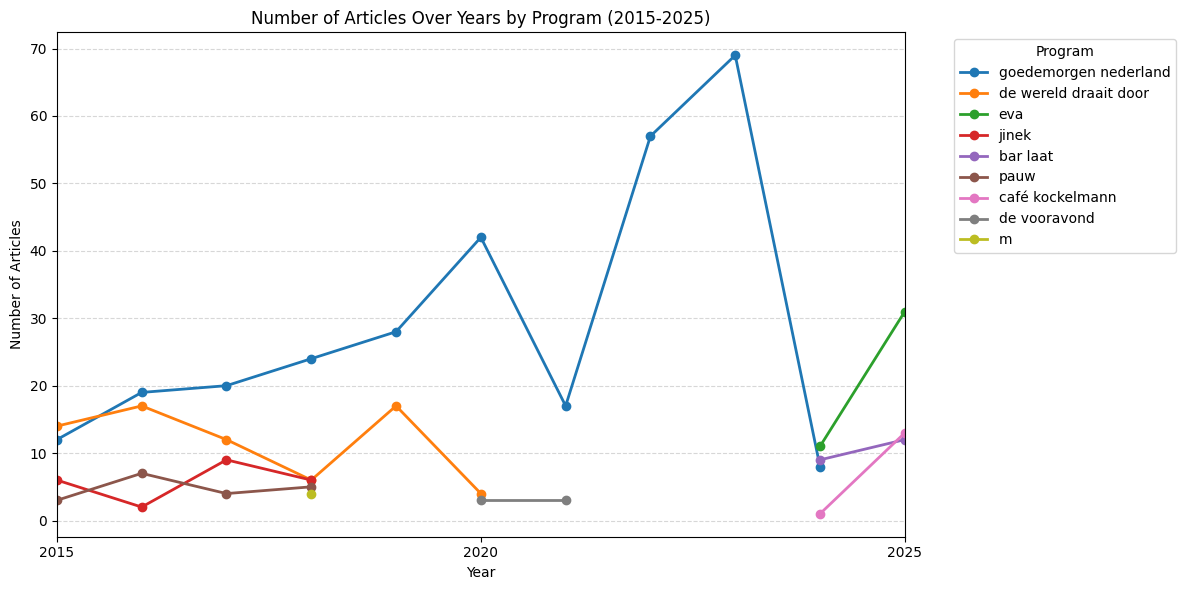

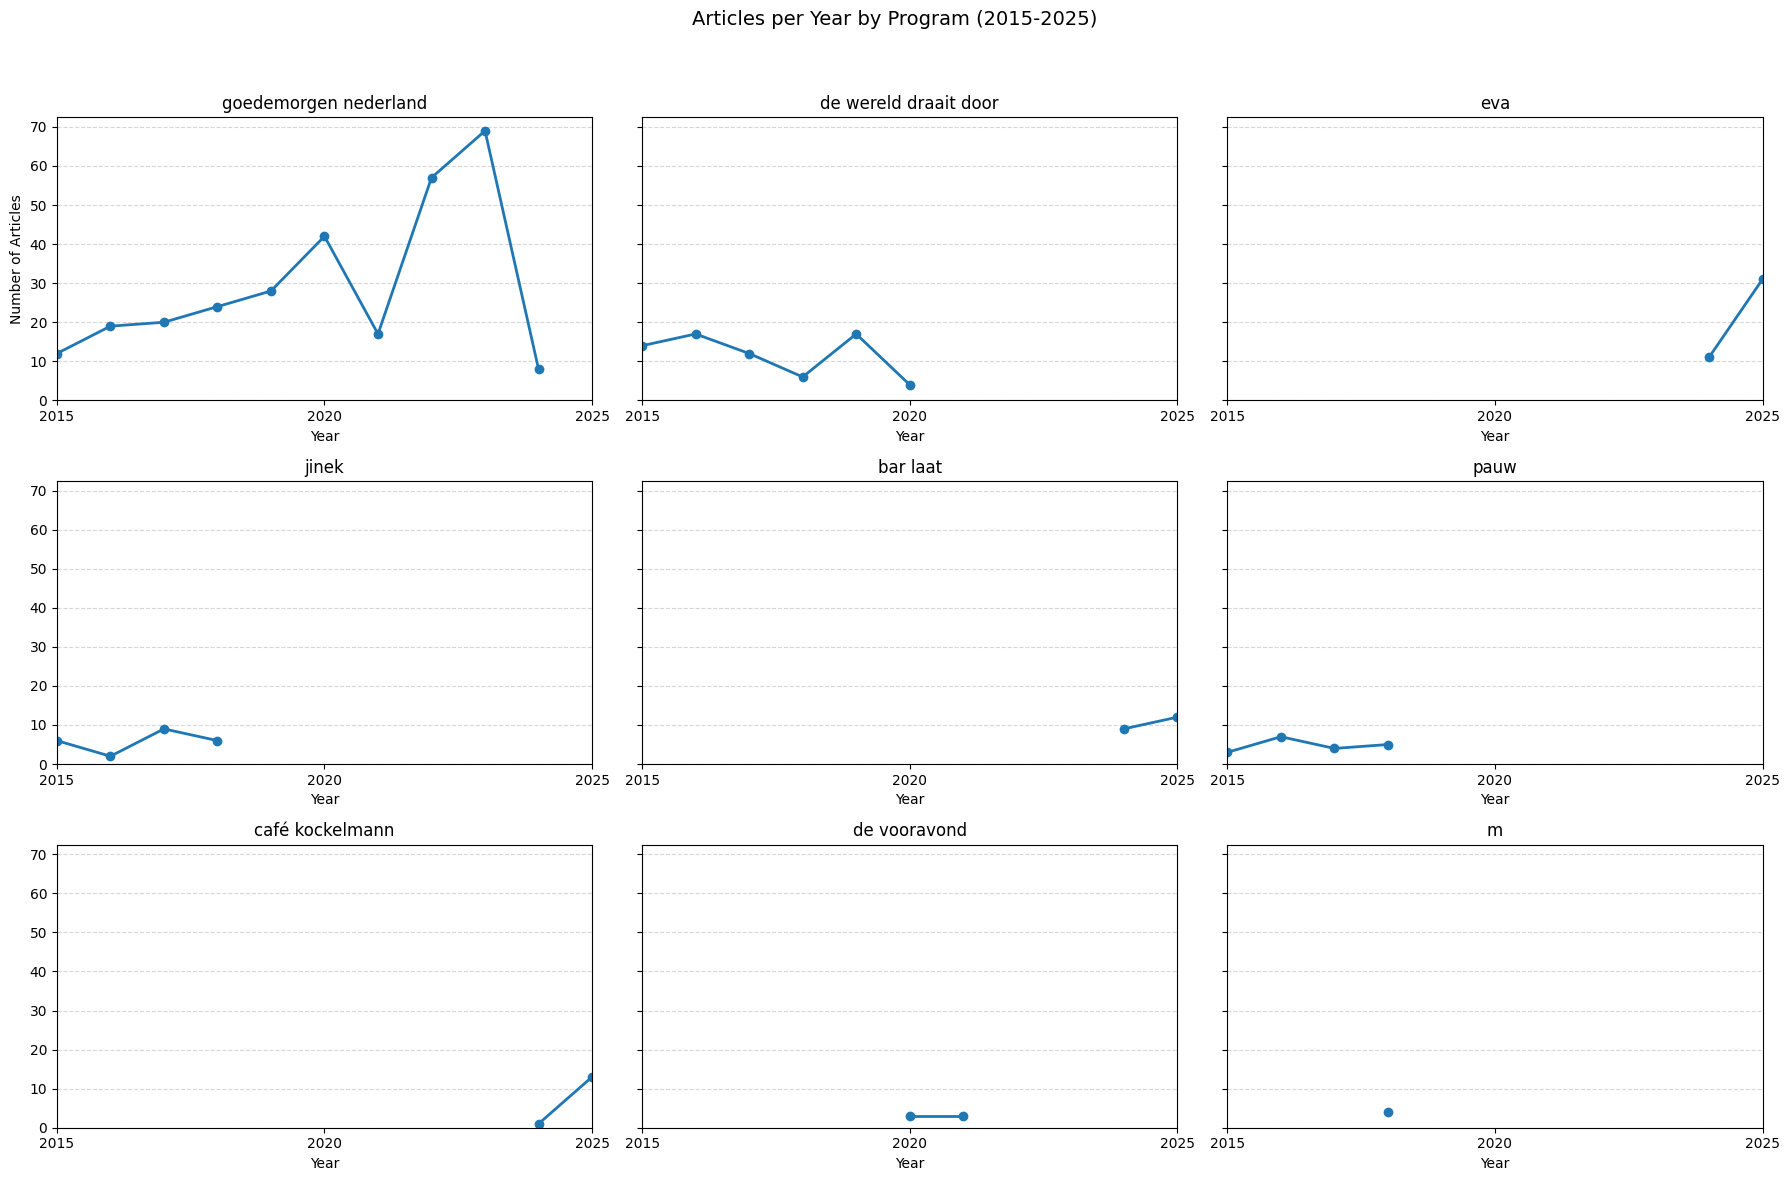

In [13]:
# ===== Config (tweak as needed) =====
TOP_OUTLETS   = None   # e.g. 6 to only show top-6 by volume; None = all
START_YEAR    = None   # e.g. 2000 to force a fixed start
END_YEAR      = None   # e.g. 2024 to force a fixed end
FIVE_YEAR_TICKS = True

# Prep
d = df[['program','year']].dropna().copy()
d['year'] = d['year'].astype(int)

# Count the number of articles per program per year
articles_per_year = (
    d.groupby(['program','year'])
     .size()
     .reset_index(name='count')
     .sort_values(['program','year'])
)

# Which programs (optionally top-N by total volume)?
totals = articles_per_year.groupby('program')['count'].sum().sort_values(ascending=False)
programs = totals.index.tolist() if TOP_OUTLETS is None else totals.head(TOP_OUTLETS).index.tolist()

# Year range (auto unless overridden)
yr_min = int(articles_per_year['year'].min()) if START_YEAR is None else int(START_YEAR)
yr_max = int(articles_per_year['year'].max()) if END_YEAR   is None else int(END_YEAR)

def five_year_ticks(start, end):
    start5 = (start // 5) * 5
    step   = 5 if (end - start) >= 5 else 1
    return np.arange(start5, end + 1, step)

# =========================
# 1) Combined plot (all outlets)
# =========================
plt.figure(figsize=(12, 6))
for program in programs:
    od = articles_per_year[articles_per_year['program'] == program]
    plt.plot(od['year'], od['count'], marker='o', linewidth=2, label=program)

plt.xlim(yr_min, yr_max)
if FIVE_YEAR_TICKS:
    plt.xticks(five_year_ticks(yr_min, yr_max))
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.title(f'Number of Articles Over Years by Program ({yr_min}-{yr_max})')
plt.legend(title='Program', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =========================
# 2) Facet: one graph per program
# =========================
n = len(programs)
ncols = 3 if n >= 3 else n
nrows = ceil(n / ncols) if n else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
axes = np.atleast_1d(axes).flatten()

# consistent y-limit for comparability
global_ymax = articles_per_year['count'].max()

for ax, program in zip(axes, programs):
    od = articles_per_year[articles_per_year['program'] == program].copy()
    ax.plot(od['year'], od['count'], marker='o', linewidth=2)

    ax.set_xlim(yr_min, yr_max)
    if FIVE_YEAR_TICKS:
        ax.set_xticks(five_year_ticks(yr_min, yr_max))
    ax.set_ylim(0, global_ymax * 1.05)

    ax.set_title(program)
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_xlabel('Year')

# tidy layout
for j in range(len(programs), len(axes)):
    axes[j].axis('off')
axes[0].set_ylabel('Number of Articles')

fig.suptitle(f'Articles per Year by Program ({yr_min}-{yr_max})', y=0.98, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [21]:
counts_wide = pd.crosstab(df['program'], df['year'])
# with totals:
# counts_wide = pd.crosstab(df['news_brand'], df['year'], margins=True, margins_name='Total')
counts_wide


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
program,,,,,,,,,,,
bar laat,0,0,0,0,0,0,0,0,0,9,12
café kockelmann,0,0,0,0,0,0,0,0,0,1,13
de vooravond,0,0,0,0,0,3,3,0,0,0,0
de wereld draait door,14,17,12,6,17,4,0,0,0,0,0
eva,0,0,0,0,0,0,0,0,0,11,31
goedemorgen nederland,12,19,20,24,28,42,17,57,69,8,0
jinek,6,2,9,6,0,0,0,0,0,0,0
m,0,0,0,4,0,0,0,0,0,0,0
pauw,3,7,4,5,0,0,0,0,0,0,0


In [22]:
#proportion of migration articles vs total
counts = pd.read_excel('../data/articles_per_year_by_program.xlsx')
counts

,year,bar laat,café kockelmann,de vooravond,de wereld draait door,eva,goedemorgen nederland,jinek,m,pauw
0,2015,0,0,0,168,0,295,77,0,140
1,2016,0,0,0,159,0,649,39,0,123
2,2017,0,0,0,164,0,733,118,0,119
3,2018,0,0,0,117,0,658,64,23,63
4,2019,0,0,0,131,0,720,0,0,0
5,2020,0,0,38,59,0,1199,0,0,0
6,2021,0,0,65,0,0,1222,0,0,0
7,2022,0,0,0,0,0,1191,0,0,0
8,2023,0,0,0,0,0,1218,0,0,0
9,2024,69,17,0,0,63,35,0,0,0


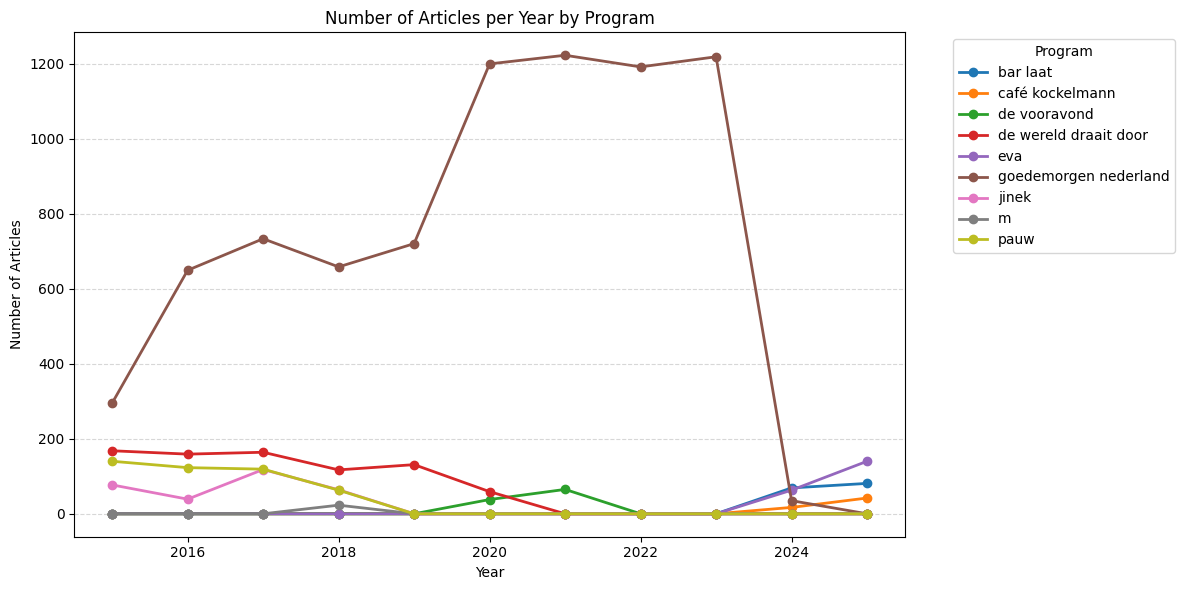

In [23]:
# plot distribution of articles per year for each program
plt.figure(figsize=(12, 6))
for program in counts.columns[1:]:  # skip 'year' column
    plt.plot(counts['year'], counts[program], marker='o', linewidth=2, label=program)
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.title('Number of Articles per Year by Program')
plt.legend(title='Program', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

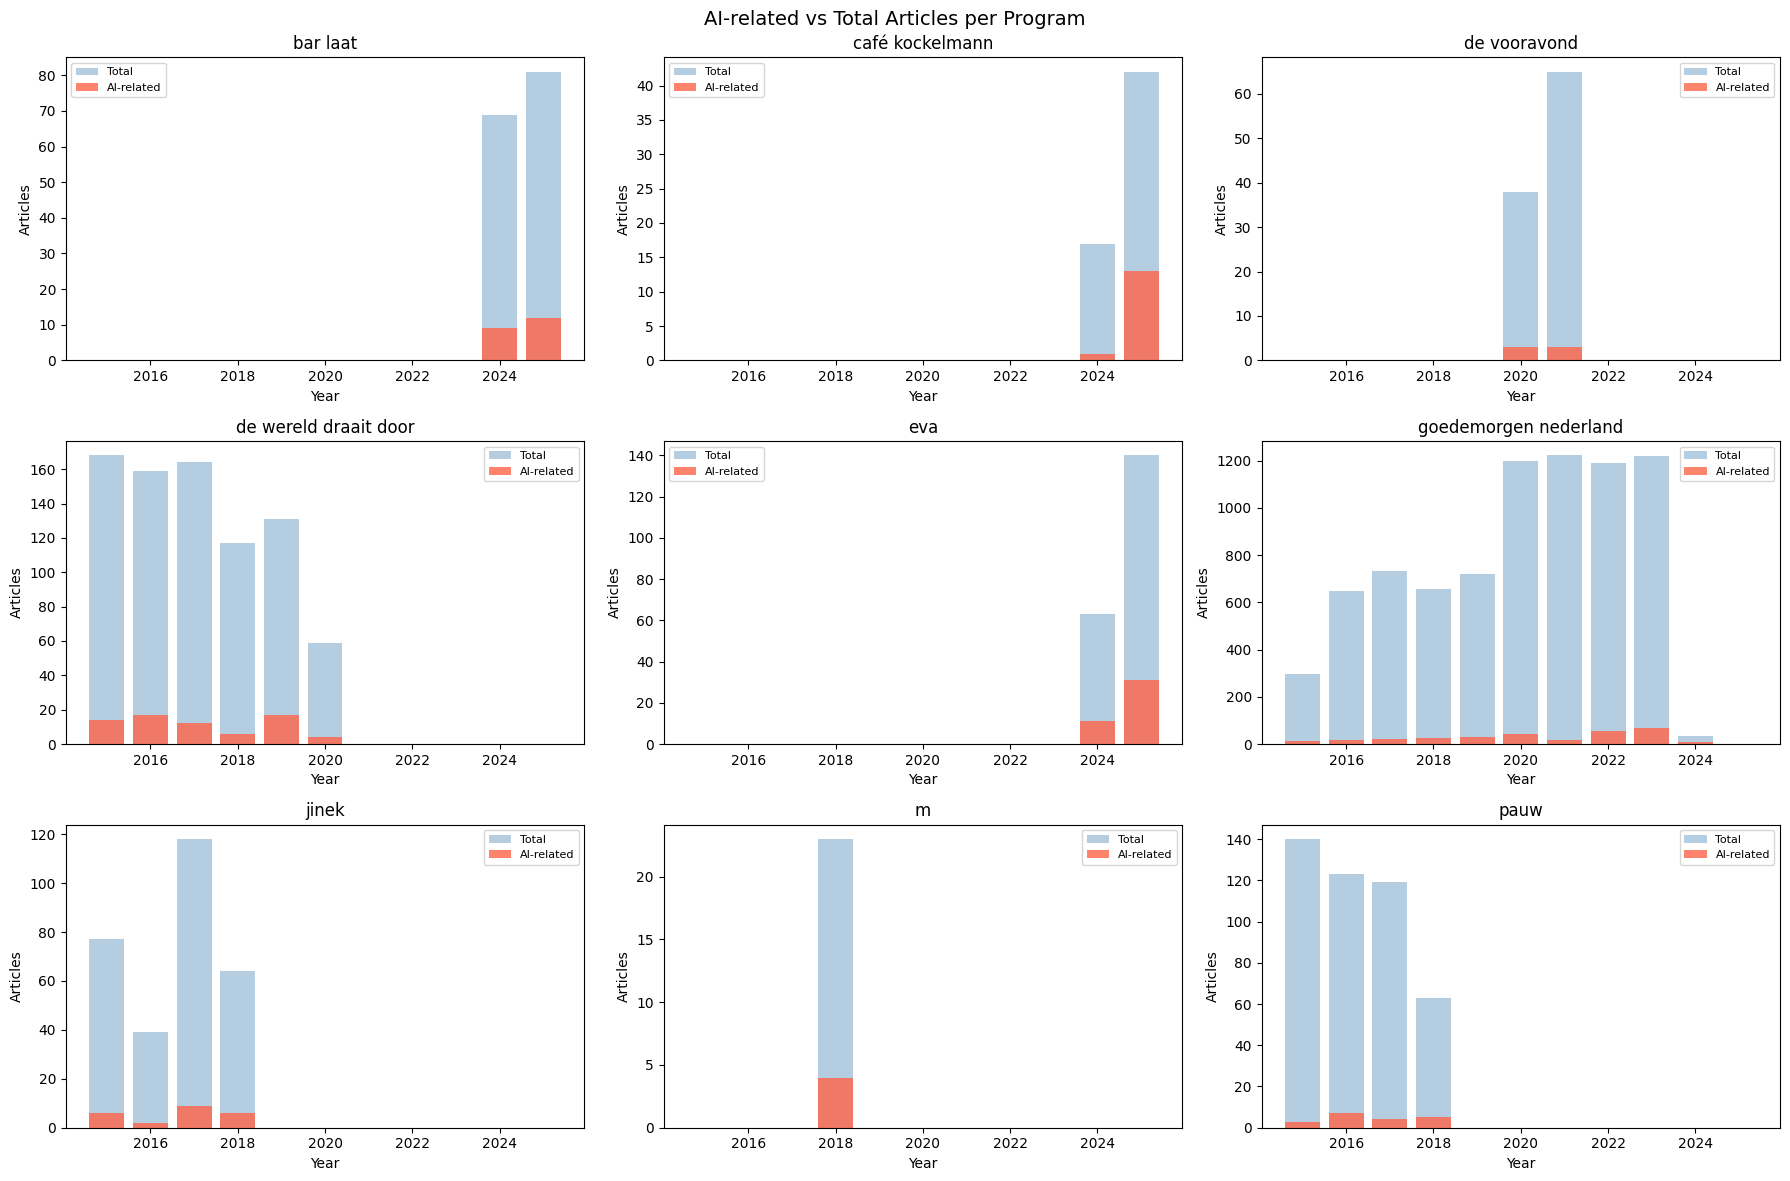

In [24]:
programs = [c for c in counts.columns if c != 'year']

# AI counts per program per year
ai_counts = (
    df.groupby(['program', 'year'])
      .size()
      .rename('ai_n')
      .reset_index()
)

# Total counts: wide → long
total_counts = counts.melt(id_vars='year', value_vars=programs,
                           var_name='program', value_name='total_n')

# Merge
merged = total_counts.merge(ai_counts, on=['program', 'year'], how='left')
merged['ai_n'] = merged['ai_n'].fillna(0).astype(int)

# Plot: one facet per program
ncols = 3
nrows = ceil(len(programs) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.atleast_1d(axes).flatten()

for ax, program in zip(axes, programs):
    sub = merged[merged['program'] == program].sort_values('year')
    ax.bar(sub['year'], sub['total_n'], label='Total', color='steelblue', alpha=0.4)
    ax.bar(sub['year'], sub['ai_n'],    label='AI-related', color='tomato', alpha=0.8)
    ax.set_title(program)
    ax.set_xlabel('Year')
    ax.set_ylabel('Articles')
    ax.legend(fontsize=8)

for j in range(len(programs), len(axes)):
    axes[j].axis('off')

fig.suptitle('AI-related vs Total Articles per Program', fontsize=14)
plt.tight_layout()
plt.show()


## Topic Distribution per Outlet

Stacked bar charts showing what share of each outlet's AI-related articles falls into each meta-topic category (normalised to 100%).

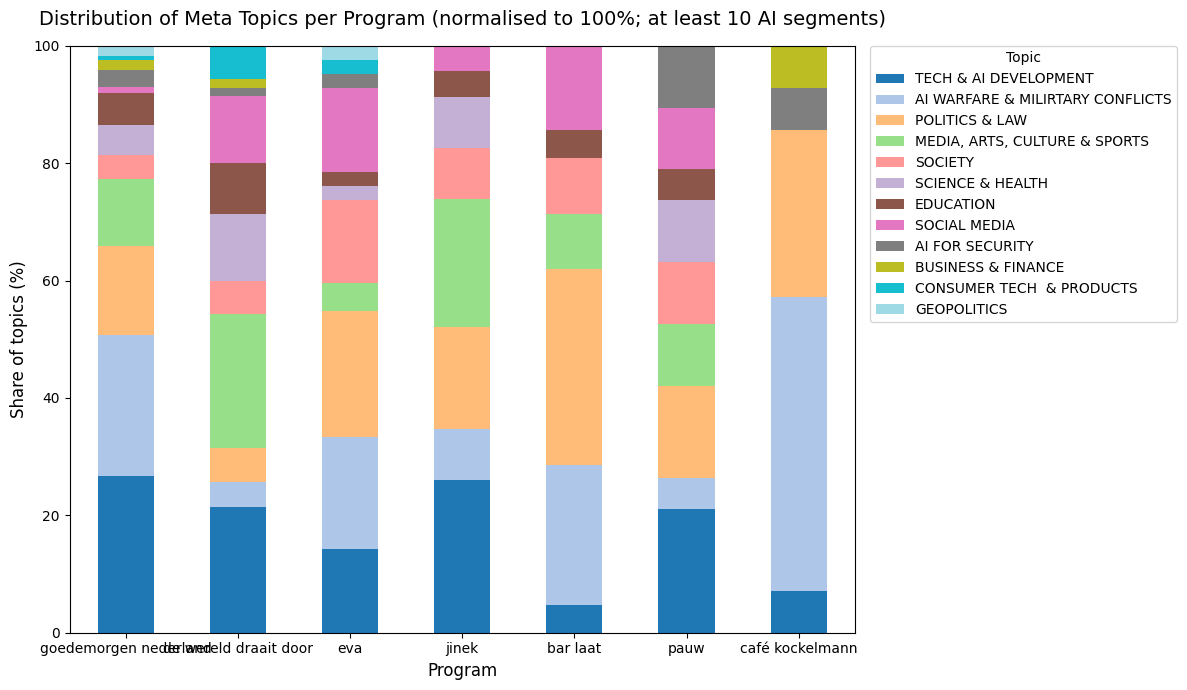

In [25]:
# =========================
# CONFIG
# =========================
BRAND_COL = "program"
TOPIC_COL = "topic_meta"

MIN_TOTAL_PER_BRAND = 10    # optional: filter out brands with very few articles
FIGSIZE = (12, 7)
ROT_X = 0                   # rotation of x-axis labels (0, 45, etc.)

# =========================
# 1) Prepare data
# =========================
# Drop missing values
df_plot = df[[BRAND_COL, TOPIC_COL]].dropna(subset=[BRAND_COL, TOPIC_COL])

# Create contingency table: counts of topics per news brand
ct = (
    df_plot
    .groupby([BRAND_COL, TOPIC_COL])
    .size()
    .unstack(fill_value=0)
)

# Filter out small brands (optional)
brand_totals = ct.sum(axis=1)
ct = ct.loc[brand_totals >= MIN_TOTAL_PER_BRAND]

# Sort topics by total frequency (for nicer order in legend)
topic_order = ct.sum(axis=0).sort_values(ascending=False).index
ct = ct[topic_order]

# Sort brands by total number of articles
brand_order = ct.sum(axis=1).sort_values(ascending=False).index
ct = ct.loc[brand_order]

# =========================
# 2) Normalise to percentages
# =========================
ct_percent = ct.div(ct.sum(axis=1), axis=0).replace([np.inf, np.nan], 0.0) * 100

# =========================
# 3) Plot
# =========================
ax = ct_percent.plot(
    kind="bar",
    stacked=True,
    figsize=FIGSIZE,
    cmap="tab20"   # nice diverse colour map
)

# Labeling and formatting
ax.set_xlabel("Program", fontsize=12)
ax.set_ylabel("Share of topics (%)", fontsize=12)
ax.set_title("Distribution of Meta Topics per Program (normalised to 100%; at least 10 AI segments)", fontsize=14, pad=15)
ax.tick_params(axis="x", labelrotation=ROT_X)

# Legend on the side for readability
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)

plt.tight_layout()
plt.show()


In [28]:
# Ensure 'created_at' is in datetime format
#df['created_at'] = pd.to_datetime(df['created_at'])

# Aggregate the data by country and meta topic to count occurrences
aggregated_meta = df.groupby(['program', 'topic_meta']).size().reset_index(name='count')

# Create a contingency table with countries as rows and meta topics as columns
contingency_table = aggregated_meta.pivot(index='program', columns='topic_meta', values='count').fillna(0)

# Perform the Chi-squared test
chi2, p, dof, ex = chi2_contingency(contingency_table)

# Identify the most significant meta topics per country
residuals = (contingency_table - ex) / ex**0.5

# Find the most significant residuals
significant_residuals = residuals.unstack().sort_values(ascending=False)

# Display results
print(f"Chi-squared Statistic: {chi2}")
print(f"P-value: {p}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies Table: \n{ex}")

# Display the top 10 most significant residuals
print("Top 10 most significant residuals:")

Chi-squared Statistic: 142.37266286170146
P-value: 0.00021804579923211294
Degrees of Freedom: 88
Expected Frequencies Table: 
[[6.36363636e-01 4.15757576e+00 2.96969697e-01 2.96969697e-01
  1.10303030e+00 2.54545455e-01 2.63030303e+00 3.30909091e+00
  1.18787879e+00 1.01818182e+00 1.18787879e+00 4.92121212e+00]
 [4.24242424e-01 2.77171717e+00 1.97979798e-01 1.97979798e-01
  7.35353535e-01 1.69696970e-01 1.75353535e+00 2.20606061e+00
  7.91919192e-01 6.78787879e-01 7.91919192e-01 3.28080808e+00]
 [1.81818182e-01 1.18787879e+00 8.48484848e-02 8.48484848e-02
  3.15151515e-01 7.27272727e-02 7.51515152e-01 9.45454545e-01
  3.39393939e-01 2.90909091e-01 3.39393939e-01 1.40606061e+00]
 [2.12121212e+00 1.38585859e+01 9.89898990e-01 9.89898990e-01
  3.67676768e+00 8.48484848e-01 8.76767677e+00 1.10303030e+01
  3.95959596e+00 3.39393939e+00 3.95959596e+00 1.64040404e+01]
 [1.27272727e+00 8.31515152e+00 5.93939394e-01 5.93939394e-01
  2.20606061e+00 5.09090909e-01 5.26060606e+00 6.61818182e+00
  

In [29]:
# Aggregate the data by country and meta topic to count occurrences
aggregated_meta = df.groupby(['program', 'topic_meta']).size().reset_index(name='count')

# Create a contingency table with countries as rows and meta topics as columns
contingency_table = aggregated_meta.pivot(index='program', columns='topic_meta', values='count').fillna(0)

# Perform the Chi-squared test
chi2, p, dof, ex = chi2_contingency(contingency_table)

# Calculate residuals
residuals = (contingency_table - ex) / ex**0.5

# Flatten the residuals DataFrame and sort by residual values
significant_residuals = residuals.unstack().sort_values(ascending=False).reset_index()
significant_residuals.columns = ['Meta', 'program', 'Residual']

# Display the top 10 most significant residuals in a table
top_10_residuals = significant_residuals.head(10)
print(top_10_residuals)

                               Meta                program  Residual
0         CONSUMER TECH  & PRODUCTS  de wereld draait door  3.025420
1                      SOCIAL MEDIA                    eva  2.777577
2  AI WARFARE & MILIRTARY CONFLICTS        café kockelmann  2.539742
3                      SOCIAL MEDIA  de wereld draait door  2.500216
4     MEDIA, ARTS, CULTURE & SPORTS  de wereld draait door  2.442506
5                           SOCIETY                    eva  2.351344
6                  SCIENCE & HEALTH  de wereld draait door  2.030483
7                   POLITICS & LAW                bar laat  2.028986
8                      SOCIAL MEDIA               bar laat  1.964044
9                   AI FOR SECURITY           de vooravond  1.918806


## Most Distinctive Topics per Outlet (Chi-Square Analysis)

To identify which meta-topics are *over-* or *under-represented* per outlet relative to what would be expected by chance, we run a chi-square test of independence on the outlet × topic contingency table and inspect the standardised residuals.

A large positive residual means an outlet covers that topic significantly more than average; a large negative residual means significantly less.

In [30]:
BRAND_COL = "program"
TOPIC_COL = "topic_meta"
TOP_N = 10

# 1) Contingency table (brands × topics)
aggregated_meta = (
    df.groupby([BRAND_COL, TOPIC_COL])
      .size()
      .reset_index(name='count')
)

contingency = (
    aggregated_meta
    .pivot(index=BRAND_COL, columns=TOPIC_COL, values='count')
    .fillna(0)
    .astype(int)
)

# Drop brands/topics that are all zero (safeguard)
contingency = contingency.loc[contingency.sum(axis=1) > 0, contingency.sum(axis=0) > 0]

if contingency.empty or contingency.shape[0] < 2 or contingency.shape[1] < 2:
    raise ValueError("Not enough non-empty rows/cols to run chi-square.")

# 2) Chi-square on counts
chi2, p, dof, expected = chi2_contingency(contingency.values, correction=False)

# Wrap expected as DataFrame aligned to contingency
ex_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

# 3) Standardized residuals
# Guard: avoid divide-by-zero if any expected cell is (near) zero
den = np.sqrt(ex_df.replace(0, np.nan))
residuals = (contingency - ex_df) / den

# 4) Tidy long format (consistent column names!)
residuals_flat = (
    residuals.stack()
             .rename("Residual")
             .reset_index()
             .rename(columns={BRAND_COL: "news_brand", TOPIC_COL: "topic_meta"})
)

# 5) Split + take top/bottom per brand
positive = residuals_flat[residuals_flat["Residual"] > 0].copy()
negative = residuals_flat[residuals_flat["Residual"] < 0].copy()

def top_per_brand(df_in, n=TOP_N, ascending=False):
    return (df_in.sort_values(["news_brand", "Residual"], ascending=[True, ascending])
                 .groupby("news_brand", as_index=False)
                 .head(n))

top_pos = top_per_brand(positive, n=TOP_N, ascending=False)
top_neg = top_per_brand(negative, n=TOP_N, ascending=True)

# 6) Build summary dicts (brand → list of topics)
most_distinct = (top_pos.groupby("news_brand")["topic_meta"]
                      .apply(list)
                      .to_dict())
least_distinct = (top_neg.groupby("news_brand")["topic_meta"]
                      .apply(list)
                      .to_dict())

# 7) Assemble display table
brands_order = list(contingency.index)  # keep contingency row order
table_df = pd.DataFrame({
    "News Brand": brands_order,
    "Most Distinct Topics": [", ".join(most_distinct.get(b, [])) for b in brands_order],
    "Least Distinct Topics": [", ".join(least_distinct.get(b, [])) for b in brands_order],
})

print(table_df)

# 8) APA-style line
chi2_apa = f"χ²({dof}) = {chi2:.2f}, p < .001" if p < 0.001 else f"χ²({dof}) = {chi2:.2f}, p = {p:.3f}"
print("\nChi-squared Test Result (APA Style):")
print(chi2_apa)


              News Brand                               Most Distinct Topics  \
0               bar laat  POLITICS & LAW , SOCIAL MEDIA, SOCIETY, AI WAR...   
1        café kockelmann  AI WARFARE & MILIRTARY CONFLICTS, BUSINESS & F...   
2           de vooravond  AI FOR SECURITY, TECH & AI DEVELOPMENT, POLITI...   
3  de wereld draait door  CONSUMER TECH  & PRODUCTS, SOCIAL MEDIA, MEDIA...   
4                    eva  SOCIAL MEDIA, SOCIETY, POLITICS & LAW , GEOPOL...   
5  goedemorgen nederland  AI WARFARE & MILIRTARY CONFLICTS, TECH & AI DE...   
6                  jinek  MEDIA, ARTS, CULTURE & SPORTS, SCIENCE & HEALT...   
7                      m  SOCIAL MEDIA, MEDIA, ARTS, CULTURE & SPORTS, A...   
8                   pauw  AI FOR SECURITY, SOCIAL MEDIA, SCIENCE & HEALT...   

                               Least Distinct Topics  
0  TECH & AI DEVELOPMENT, SCIENCE & HEALTH, AI FO...  
1  MEDIA, ARTS, CULTURE & SPORTS, TECH & AI DEVEL...  
2  AI WARFARE & MILIRTARY CONFLICTS, MEDIA, 

In [31]:
table_df.to_excel('distinct_topics.xlsx')

In [32]:
df['year'].value_counts()

year
2023    69
2022    57
2025    56
2020    49
2016    45
2017    45
2018    45
2019    45
2015    35
2024    29
2021    20
Name: count, dtype: int64

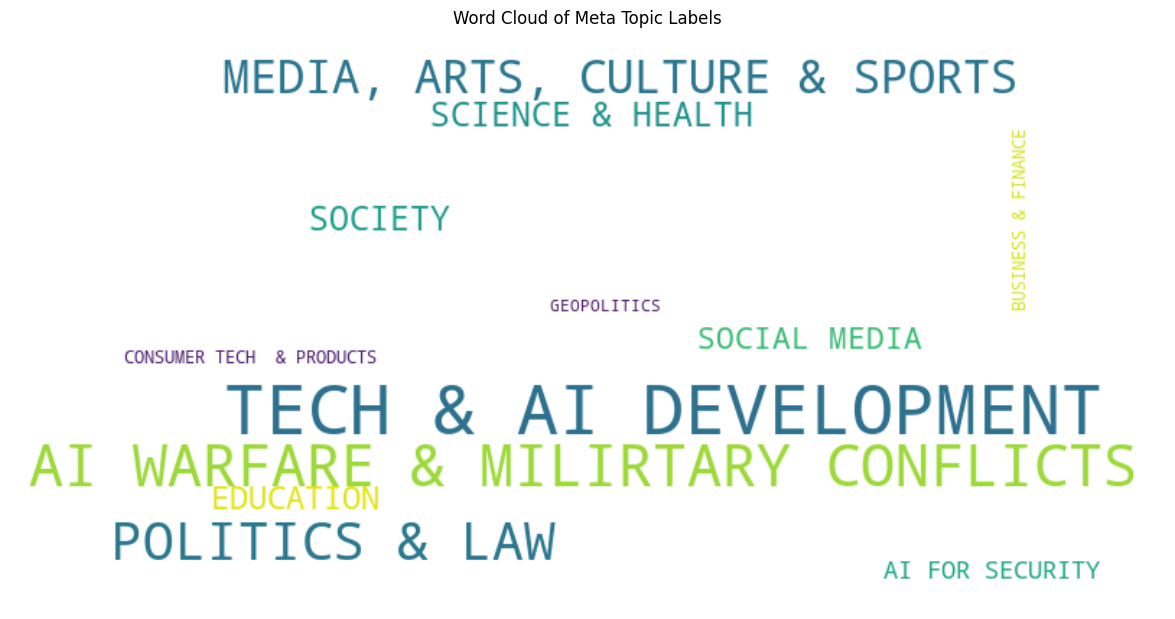

In [33]:
#word cloud meta topics
from wordcloud import WordCloud

# 2) Compute frequencies of each label
label_counts = df['topic_meta'].value_counts().to_dict()

# 3) Create a WordCloud object
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    collocations=False  # ensure multi‐word labels are kept intact
)

# 4) Generate the cloud from your frequencies
wc.generate_from_frequencies(label_counts)

# 5) Display it
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Meta Topic Labels')
plt.show()


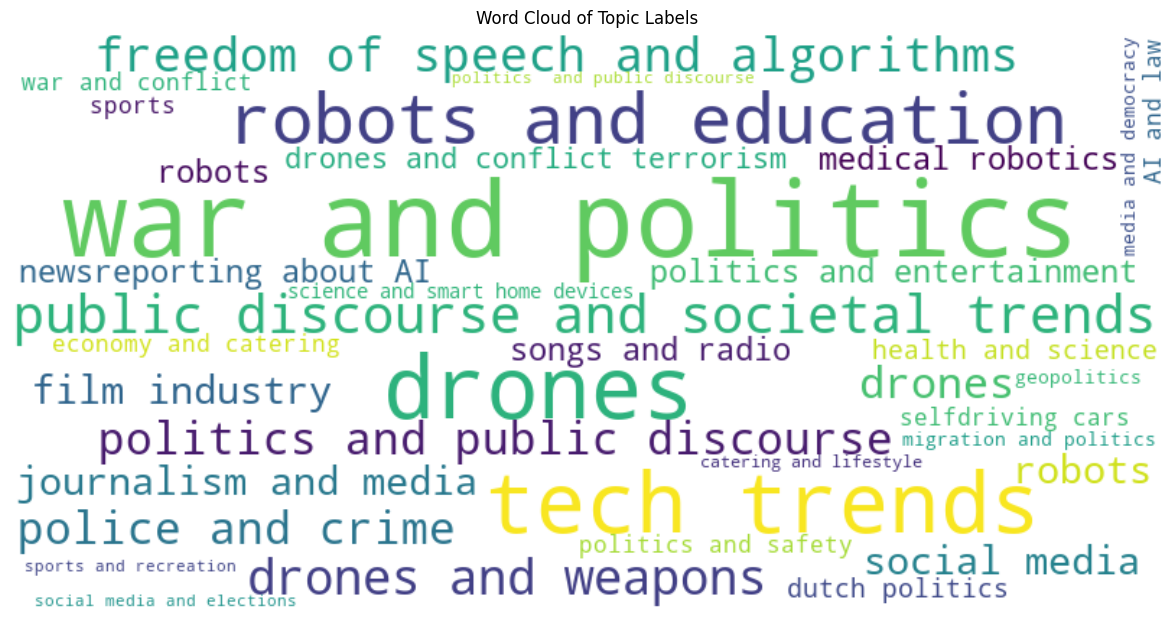

In [34]:
#word cloud labels

# 2) Compute frequencies of each label
label_counts = df['topic_label'].value_counts().to_dict()

# 3) Create a WordCloud object
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    collocations=False  # ensure multi‐word labels are kept intact
)

# 4) Generate the cloud from your frequencies
wc.generate_from_frequencies(label_counts)

# 5) Display it
plt.figure(figsize=(15, 7.5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Topic Labels')
plt.show()


## Topic Visualisations

Word clouds and bar charts summarising the overall distribution of meta-topics and sub-topic labels across the full dataset.

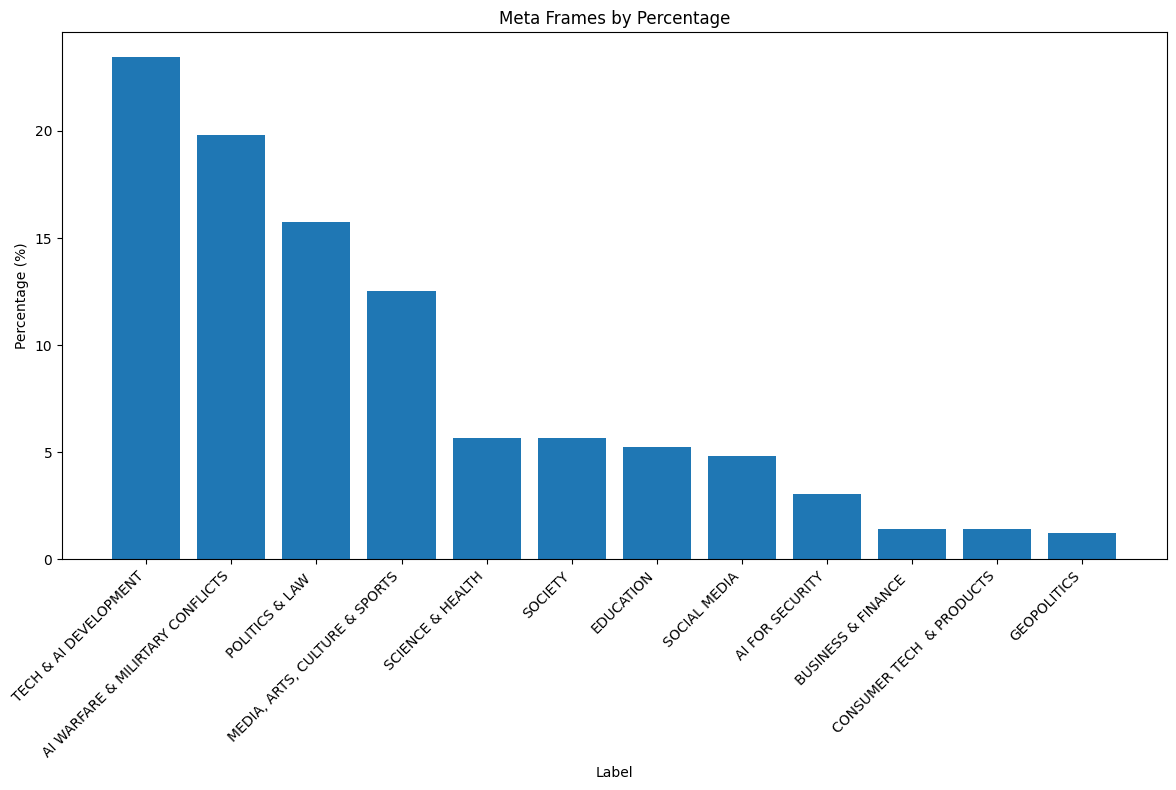

In [35]:
# Overview macro topics (percentages instead of raw counts)
meta_percent = df['topic_meta'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 8))
plt.bar(meta_percent.index, meta_percent.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('Percentage (%)')
plt.title('Meta Frames by Percentage')
plt.tight_layout()
plt.show()


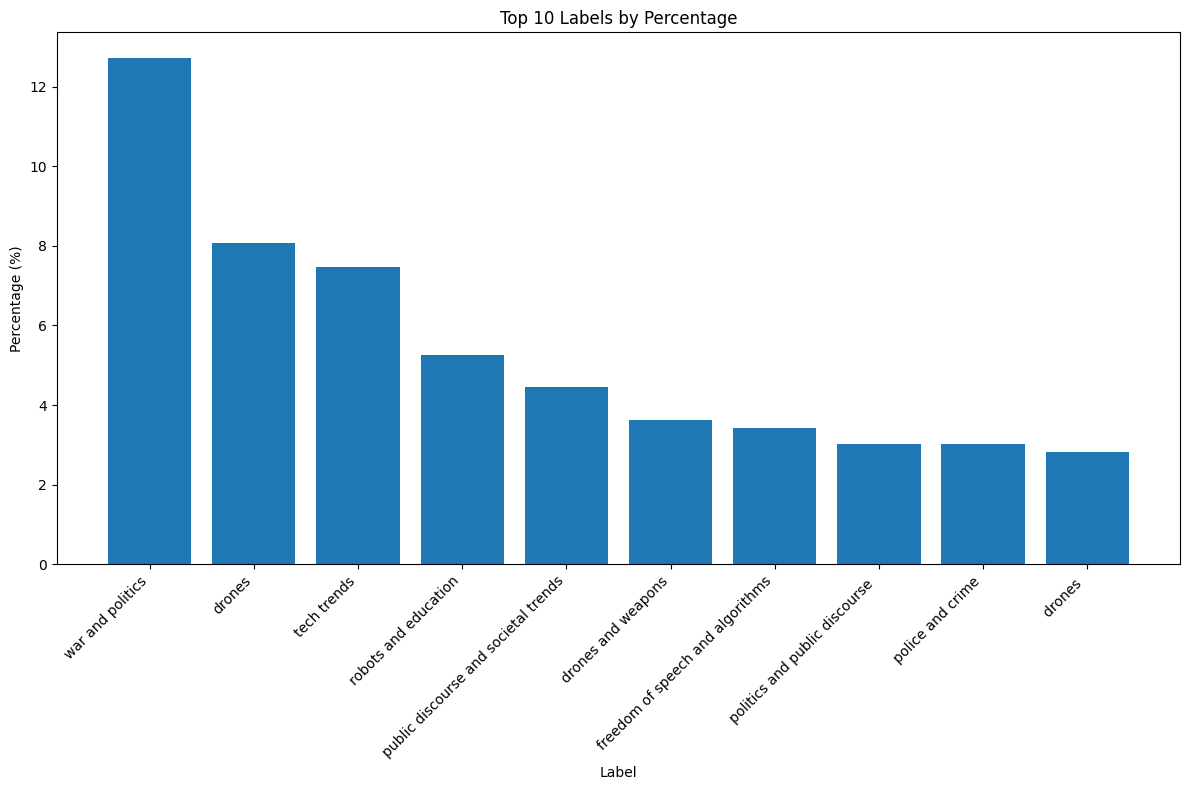

In [36]:
# Set how many top labels you want to display
top_n = 10   # ← change this to whatever you need

# Compute percentages
label_percent = df['topic_label'].value_counts(normalize=True) * 100

# Keep only the top X
label_percent_top = label_percent.head(top_n)

plt.figure(figsize=(12, 8))
plt.bar(label_percent_top.index, label_percent_top.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Label')
plt.ylabel('Percentage (%)')
plt.title(f'Top {top_n} Labels by Percentage')
plt.tight_layout()
plt.show()


## Topic Distribution per Year

Each subplot shows the top-N meta-topics (as % of all articles that year), making it easy to compare how the topic mix shifts year by year.

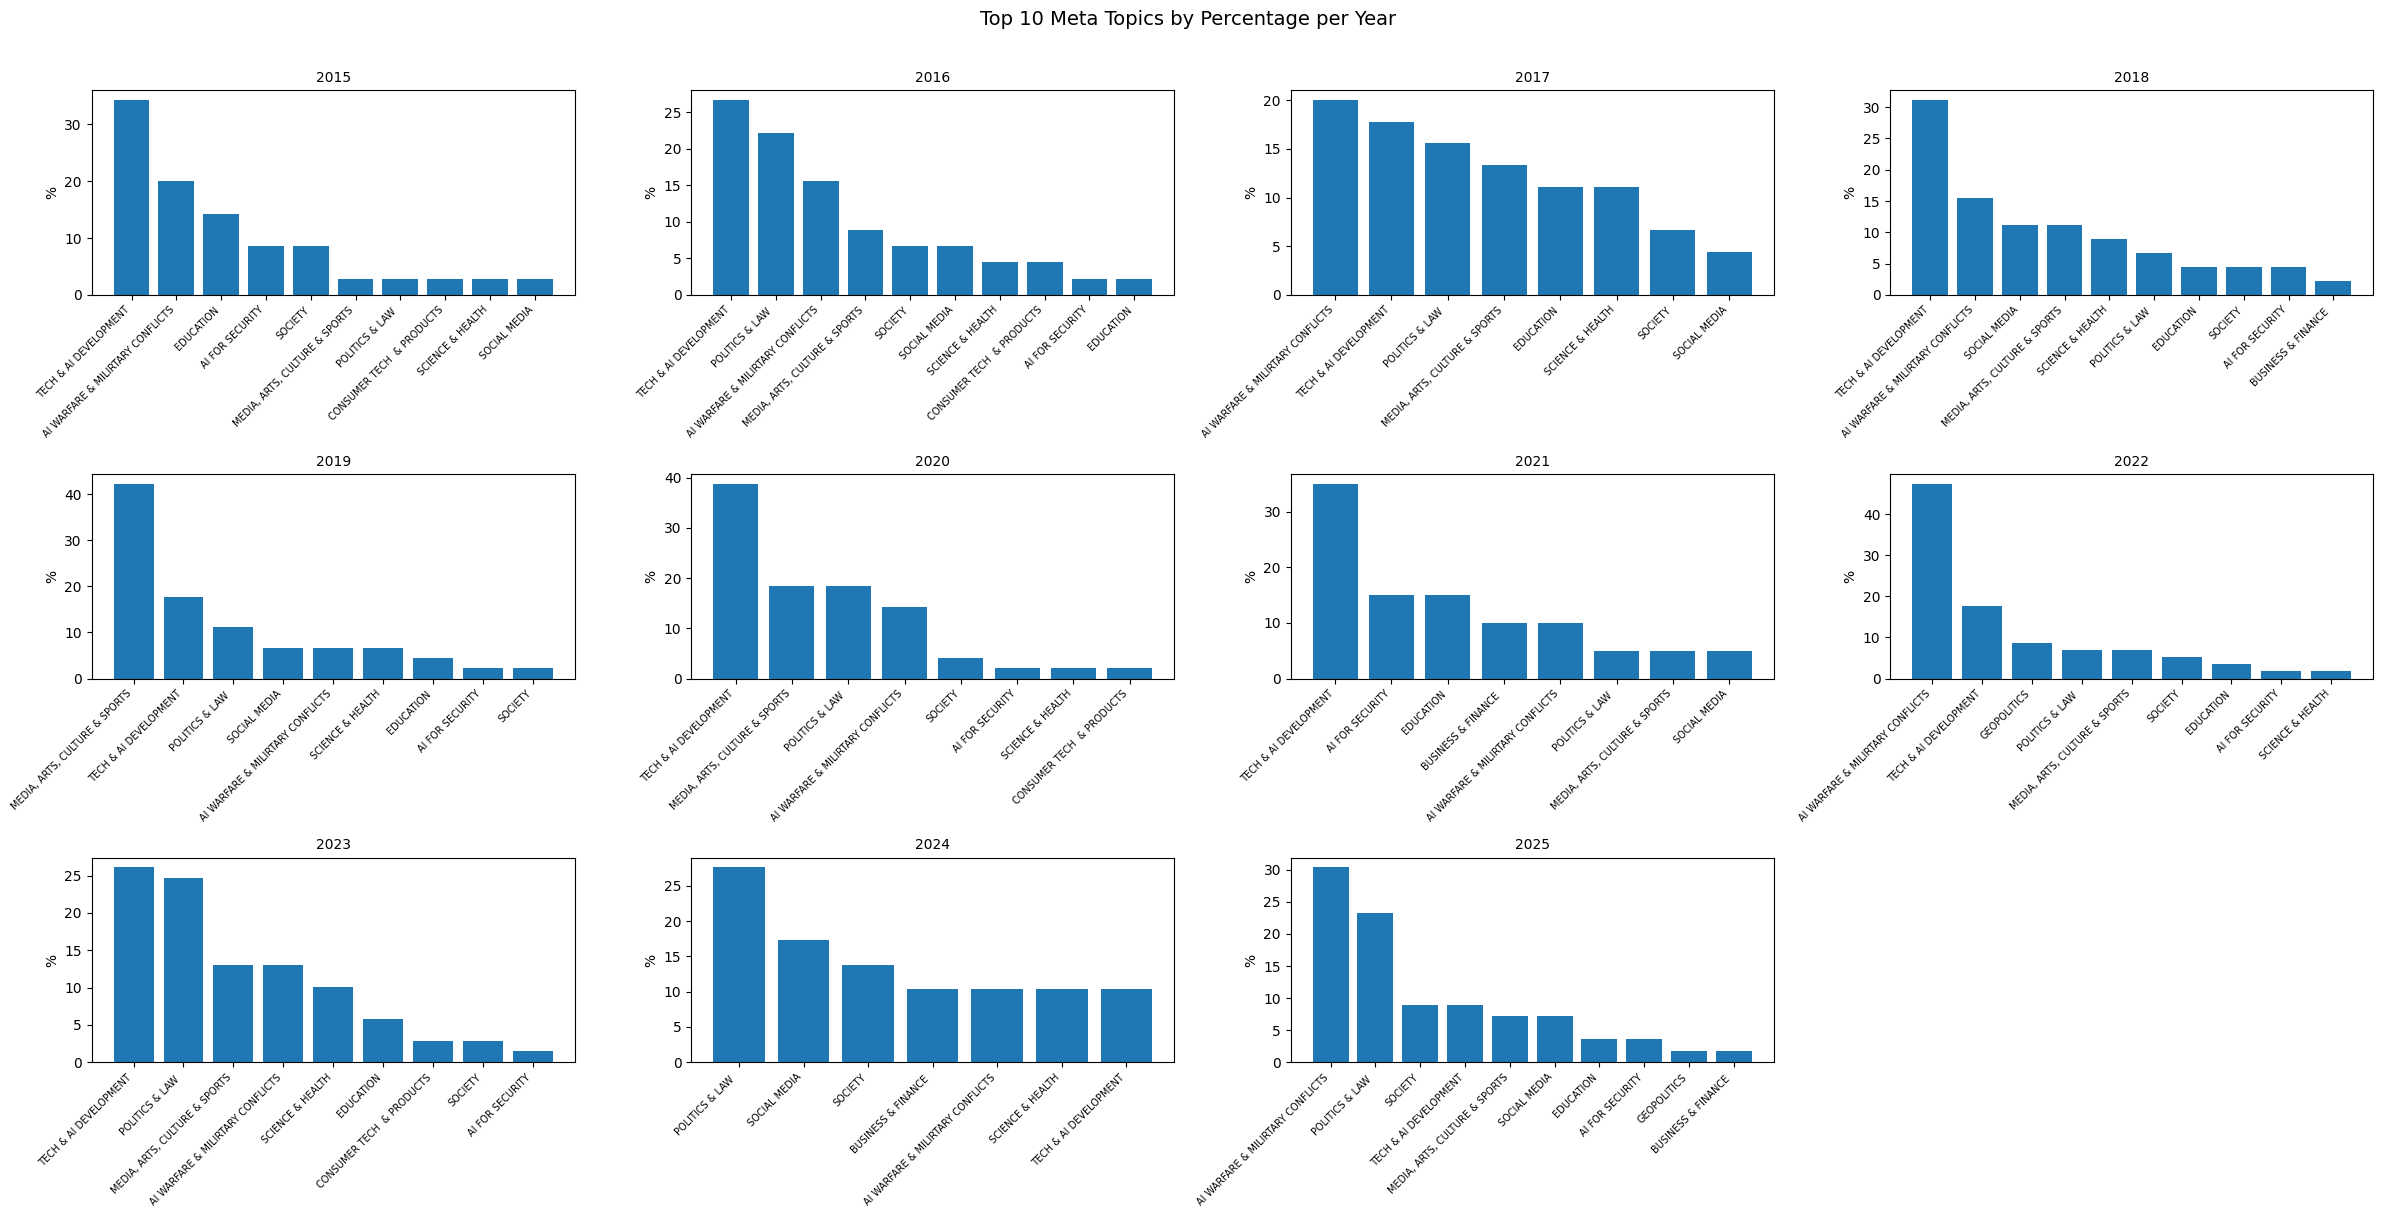

In [37]:
#Bar chart per year - adjust to macro, meta or label
top_n = 10  # number of labels to display per year
label = 'Meta'  #'Macro' #'Meta' #'Label'

years = sorted(df['year'].unique())

ncols = 4
nrows = ceil(len(years) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.atleast_1d(axes).flatten()

for ax, yr in zip(axes, years):
    df_year = df[df['year'] == yr]
    label_percent_top = (
        df_year['topic_meta']
        .value_counts(normalize=True)
        .mul(100)
        .sort_values(ascending=False)
        .head(top_n)
    )
    ax.bar(range(len(label_percent_top)), label_percent_top.values)
    ax.set_xticks(range(len(label_percent_top)))
    ax.set_xticklabels(label_percent_top.index, rotation=45, ha='right', fontsize=7)
    ax.set_title(str(yr), fontsize=10)
    ax.set_ylabel('%')

for j in range(len(years), len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Top {top_n} {label} Topics by Percentage per Year', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Topic Trends Over Time

Line charts showing how the share of each meta-topic evolves across the full time period (2015–2025). The highlighted version draws attention to the five most frequent topics while graying out the rest.

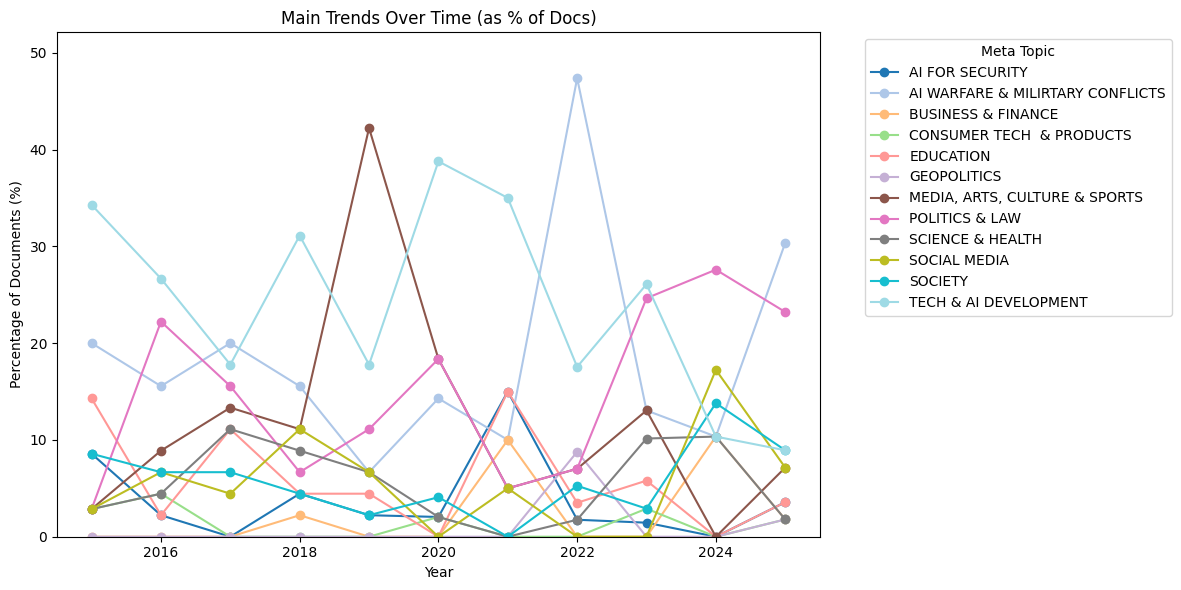

In [38]:
# 1. Build counts per year × meta-topic
counts = (
    df
    .groupby(['year', 'topic_meta'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# 2. Convert to percentages per year
pct = counts.div(counts.sum(axis=1), axis=0) * 100

# 3. Pick a qualitative colormap with exactly as many bins as you have topics
n_topics = pct.shape[1]
cmap = plt.get_cmap('tab20', n_topics)   # swap in 'tab20b', 'gist_ncar', etc. if you exceed 20
colors = cmap(np.arange(n_topics))

# 4. Plot each line
plt.figure(figsize=(12, 6))
for color, topic in zip(colors, pct.columns):
    plt.plot(
        pct.index,          # x = year
        pct[topic],         # y = % share
        marker='o',
        label=topic,
        color=color
    )

# 5. Tidy up
plt.xlabel('Year')
plt.ylabel('Percentage of Documents (%)')
plt.title('Main Trends Over Time (as % of Docs)')
plt.ylim(0, pct.values.max() * 1.1)  # add some headroom
plt.legend(
    title='Meta Topic',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()


In [39]:
# pick the top X most frequent
meta_counts = df['topic_meta'].value_counts()
toptopics = meta_counts.head(5).index.tolist()
toptopics

['TECH & AI DEVELOPMENT',
 'AI WARFARE & MILIRTARY CONFLICTS',
 'POLITICS & LAW ',
 'MEDIA, ARTS, CULTURE & SPORTS',
 'SCIENCE & HEALTH']

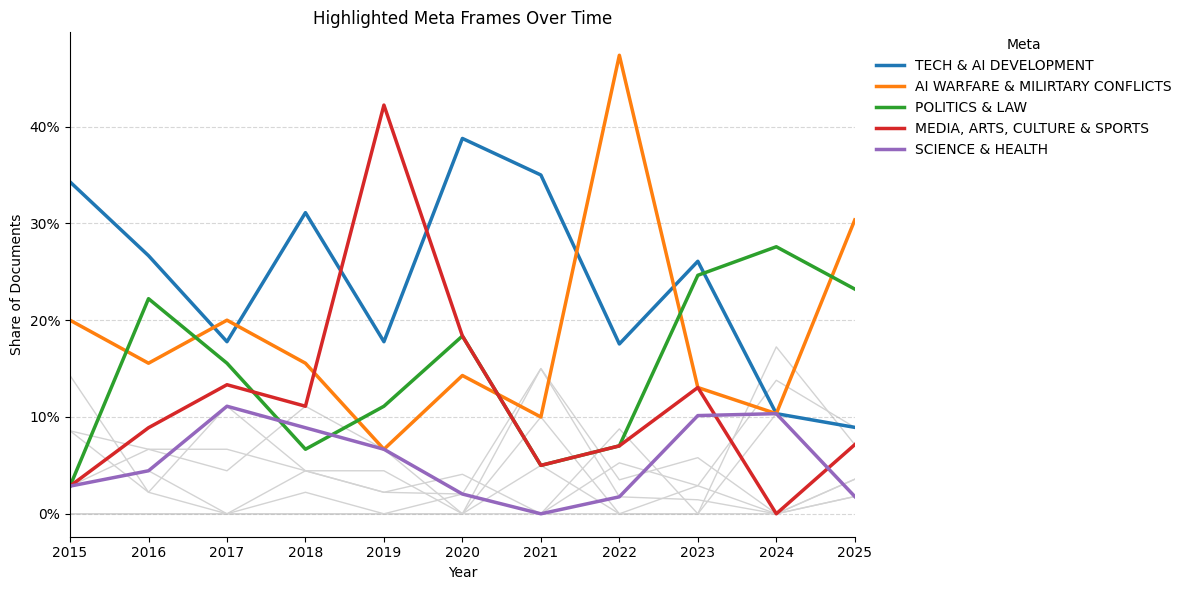

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

# plot all lines in light grey
for col in pct.columns:
    ax.plot(pct.index, pct[col], color='lightgrey', linewidth=1, zorder=1)

# highlight selected topics
for topic, color in zip(toptopics, plt.get_cmap('tab10').colors):
    ax.plot(pct.index, pct[topic], 
            label=topic, 
            color=color, 
            linewidth=2.5, 
            zorder=2)

# axes, labels & formatting
ax.set_xlim(pct.index.min(), pct.index.max())
ax.set_xlabel('Year')
ax.set_ylabel('Share of Documents')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.set_xticks(pct.index)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.title('Highlighted Meta Frames Over Time')

# ─── Legend outside plot ─────────────────────────────────
ax.legend(
    title="Meta",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
    frameon=False
)

plt.tight_layout()
plt.show()
